In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("AgriSense Analysis Started")

AgriSense Analysis Started


# Load historical agriculture data

In [6]:
historical_df = pd.read_csv("agridata.csv")

print("Dataset Shape:", historical_df.shape)
print("\nColumns:")
print(historical_df.columns.tolist())

historical_df.head()

Dataset Shape: (175628, 8)

Columns:
['state', 'district', 'crop', 'year', 'season', 'area', 'production', 'yield']


,state,district,crop,year,season,area,production,yield
0,ANDHRA PRADESH,ADILABAD,Rice,1998-99,Kharif,66400.0,152300.0,2.293675
1,ANDHRA PRADESH,ADILABAD,Rice,1998-99,Rabi,12200.0,33500.0,2.745902
2,ANDHRA PRADESH,ADILABAD,Rice,1999-00,Kharif,66388.0,162451.0,2.446993
3,ANDHRA PRADESH,ADILABAD,Rice,1999-00,Rabi,10980.0,26616.0,2.424044
4,ANDHRA PRADESH,ADILABAD,Rice,2000-01,Kharif,70645.0,146235.0,2.069998


In [4]:
historical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175628 entries, 0 to 175627
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   state       175628 non-null  object 
 1   district    175628 non-null  object 
 2   crop        175628 non-null  object 
 3   year        175627 non-null  object 
 4   season      175628 non-null  object 
 5   area        175624 non-null  float64
 6   production  173069 non-null  float64
 7   yield       173069 non-null  float64
dtypes: float64(3), object(5)
memory usage: 10.7+ MB


In [5]:
historical_df.isnull().sum()

state            0
district         0
crop             0
year             1
season           0
area             4
production    2559
yield         2559
dtype: int64

In [6]:
historical_df.describe(include="all")

,state,district,crop,year,season,area,production,yield
count,175628,175628,175628,175627,175628,1.756240e+05,1.730690e+05,173069.000000
unique,33,646,50,16,6,NaN,NaN,NaN
top,UTTAR PRADESH,BILASPUR,Rice,2003-04,Kharif,NaN,NaN,NaN
freq,23402,719,11034,14429,71225,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,1.223386e+04,2.230244e+05,18.507393
std,NaN,NaN,NaN,NaN,NaN,3.910551e+04,9.256260e+06,393.939919
min,NaN,NaN,NaN,NaN,NaN,4.000000e-02,0.000000e+00,0.000000
25%,NaN,NaN,NaN,NaN,NaN,9.000000e+01,9.900000e+01,0.501167
50%,NaN,NaN,NaN,NaN,NaN,6.430000e+02,7.800000e+02,1.000000
75%,NaN,NaN,NaN,NaN,NaN,4.826250e+03,7.256000e+03,2.207871


In [8]:
print("Columns:")
print(historical_df.columns.tolist())

print("\nStates:")
print(historical_df["state"].unique())

print("\nDoes Bhiwani exist?")
print((historical_df["district"].astype(str).str.upper() == "BHIWANI").any())

Columns:
['state', 'district', 'crop', 'year', 'season', 'area', 'production', 'yield']

States:
['ANDHRA PRADESH' 'ASSAM' 'BIHAR' 'CHHATTISGARH' 'GUJARAT' 'HARYANA'
 'HIMACHAL PRADESH' 'JAMMU & KASHMIR' 'JHARKHAND' 'KARNATAKA' 'KERALA'
 'MADHYA PRADESH' 'MAHARASHTRA' 'ORISSA' 'PUNJAB' 'RAJASTHAN' 'TAMIL NADU'
 'UTTAR PRADESH' 'UTTARANCHAL' 'WEST BENGAL' 'SIKKIM' 'TRIPURA'
 'A & N ISLANDS' 'CHANDIGARH' 'D & N HAVELI' 'ARUNACHAL PRADESH' 'DELHI'
 'NAGALAND' 'PONDICHERRY' 'MEGHALYA' 'MANIPUR' 'MIZORAM' 'GOA']

Does Bhiwani exist?
True


In [9]:
bhiwani_df = historical_df[
    (historical_df["state"].str.upper() == "HARYANA") &
    (historical_df["district"].str.upper() == "BHIWANI")
].copy()

print("Bhiwani records:", len(bhiwani_df))
bhiwani_df.head()

Bhiwani records: 270


,state,district,crop,year,season,area,production,yield
47588,HARYANA,BHIWANI,Rice,1998-99,Kharif,7223.0,16000.0,2.215146
47589,HARYANA,BHIWANI,Rice,1999-00,Kharif,7317.0,17000.0,2.323357
47590,HARYANA,BHIWANI,Rice,2000-01,Kharif,8159.0,20000.0,2.451281
47591,HARYANA,BHIWANI,Rice,2001-02,Kharif,7422.0,21000.0,2.829426
47592,HARYANA,BHIWANI,Rice,2002-03,Kharif,6491.0,19000.0,2.927130


In [10]:
print("Years:", bhiwani_df["year"].min(), "to", bhiwani_df["year"].max())

print("\nCrops:")
print(bhiwani_df["crop"].value_counts())

print("\nSeasons:")
print(bhiwani_df["season"].value_counts())

Years: 1998-99 to 2011-12

Crops:
crop
Rice                     14
Gram                     14
Cotton(lint)             14
Sesamum                  14
Wheat                    14
Moong                    14
Sugarcane                14
Bajra                    14
Barley                   14
Maize                    14
Moth                     13
Arhar (Tur)              13
Groundnut                12
Rapeseed &Mustard        12
Jowar                    12
Sannhamp                 11
Dry chillies              8
Onion                     8
Peas & Beans (Pulses)     8
Masoor                    7
Castor seed               6
Urad                      5
Potato                    5
Garlic                    4
HorseGram                 3
Other Kharif Pulses       3
Name: count, dtype: int64

Seasons:
season
Kharif        150
Rabi           72
Whole year     48
Name: count, dtype: int64


In [11]:
numeric_cols = ["year", "area", "production", "yield"]

for col in numeric_cols:
    bhiwani_df[col] = pd.to_numeric(bhiwani_df[col], errors="coerce")

bhiwani_df.isnull().sum()

state           0
district        0
crop            0
year          270
season          0
area            0
production     44
yield          44
dtype: int64

# Crop production analysis

In [12]:
crop_summary = (
    bhiwani_df.groupby("crop")
    .agg(
        total_area=("area", "sum"),
        total_production=("production", "sum"),
        average_yield=("yield", "mean")
    )
    .sort_values("total_production", ascending=False)
)

crop_summary

,total_area,total_production,average_yield
crop,,,
Wheat,1919823.0,6615000.0,3.394270
Bajra,2625859.0,2944000.0,1.136517
Rapeseed &Mustard,1784492.0,2305000.0,1.295515
Cotton(lint),720503.0,1470200.0,2.110188
Sugarcane,22762.0,1123000.0,50.626118
Gram,1020498.0,767000.0,0.741242
Rice,178003.0,400000.0,2.287126
Barley,98665.0,288000.0,2.798521
Potato,1275.0,24500.0,17.581114


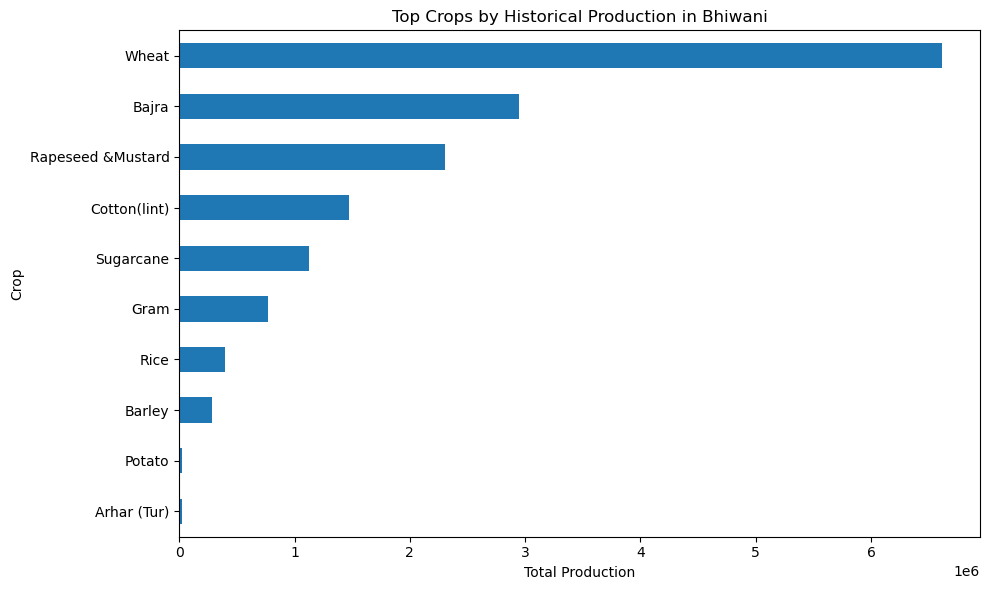

In [19]:
crop_summary["total_production"].head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top Crops by Historical Production in Bhiwani")
plt.xlabel("Total Production")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

# Historical crop production chart

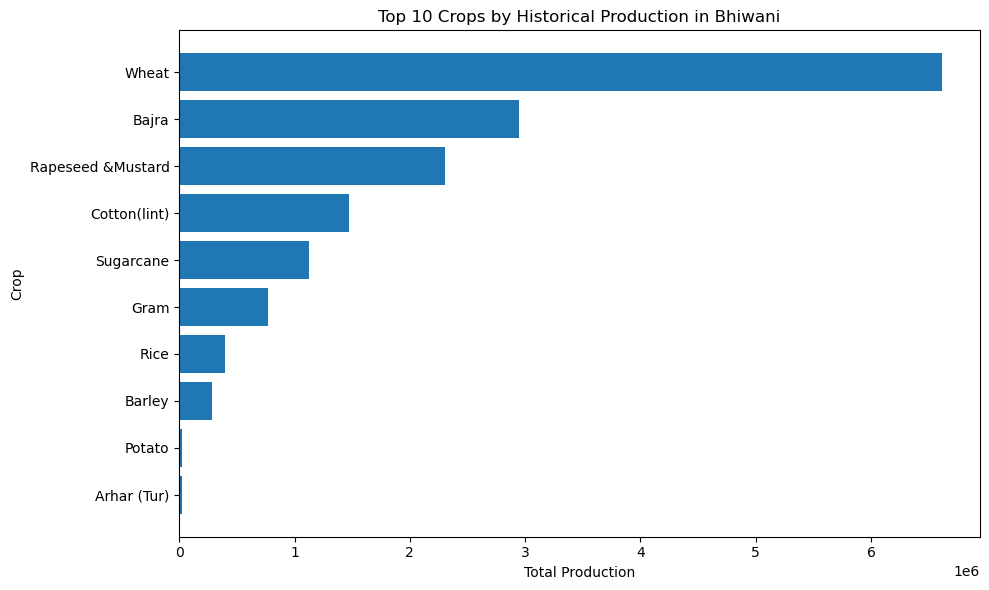

In [20]:
top_crops = crop_summary.head(10).sort_values("total_production")

plt.figure(figsize=(10, 6))

plt.barh(
    top_crops.index,
    top_crops["total_production"]
)

plt.title("Top 10 Crops by Historical Production in Bhiwani")
plt.xlabel("Total Production")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

# Historical yield chart

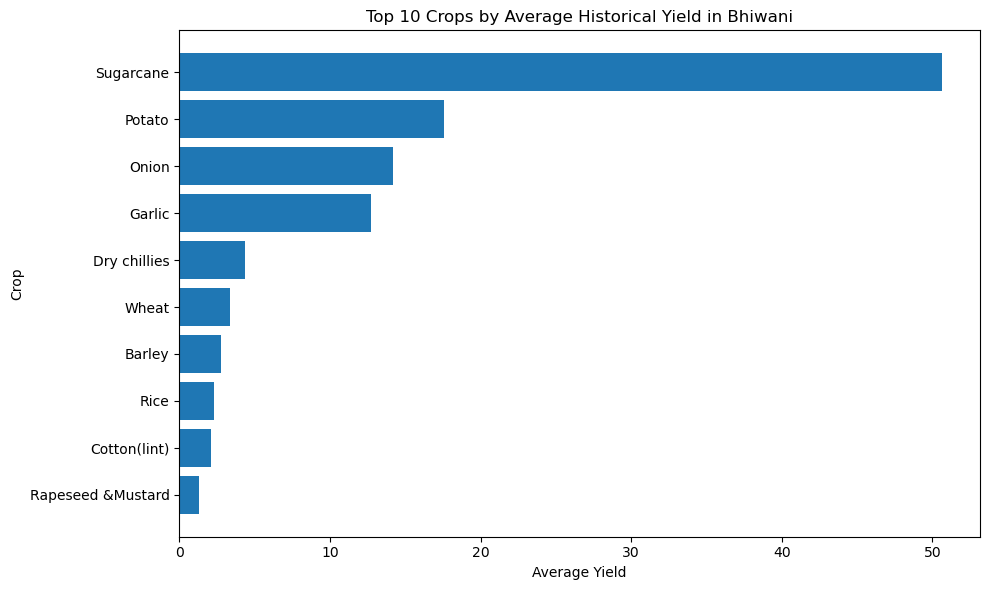

In [21]:
top_yield_crops = (
    bhiwani_df.groupby("crop")["yield"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_yield_crops.index,
    top_yield_crops.values
)

plt.title("Top 10 Crops by Average Historical Yield in Bhiwani")
plt.xlabel("Average Yield")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [23]:
import os

print(os.getcwd())

C:\Users\DELL


In [24]:
import os

print(os.listdir(r"C:\Users\DELL"))

['.anaconda', '.cache.sqlite', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.python_history', '.spyder-py3', '.swt', '.virtual_documents', '.vscode', '.vscode-shared', 'agridata.csv', 'agridata.xlsx', 'AgriSense.ipynb', 'AgriSense_Analysis.ipynb', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'iphneSale', 'jupyter DA', 'lib.py', 'Libraries', 'libraries.ipynb', 'Links', 'Local Settings', 'matplot & seaborn_practice.ipynb', 'ML Learning.ipynb', 'movies.csv', 'Music', 'My Documents', 'NetHood', 'New folder', 'New folder (2)', 'New folder (3)', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{413ec10a-6082-11ed-909a-080027ec4824}.TM.blf', 'NTUSER.DAT{413ec10a-6082-11ed-909a-080027ec4824}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{413ec10a-6082-11ed-909a-080027ec4824}

In [8]:
weather_df = pd.read_csv(
    "https://raw.githubusercontent.com/MansiDA09/AgriSense/main/data/live_weather.csv"
)

weather_df

,city,state,updated_at,temperature_c,humidity_percent,rain_mm,wind_kmh,soil_temperature_c,soil_moisture
0,Bhiwani,Haryana,2026-09-25T07:00,25.5,85,0.0,10.2,25.8,0.169


In [11]:
forecast_df = pd.read_csv(
    "https://raw.githubusercontent.com/MansiDA09/AgriSense/main/data/7_day_forecast.csv"
)

forecast_df

,date,max_temp_c,min_temp_c,mean_temp_c,rainfall_mm,et0_mm,max_wind_kmh
0,2026-09-25,32.9,25.3,28.7,0.0,5.09,15.7
1,2026-09-26,33.0,22.9,27.8,0.0,5.07,15.8
2,2026-09-27,34.0,23.5,27.9,0.4,4.51,16.6
3,2026-09-28,29.5,22.9,25.9,2.3,3.44,16.3
4,2026-09-29,33.2,22.8,27.6,0.0,4.37,13.1
5,2026-09-30,34.1,23.0,28.1,0.0,4.63,14.8
6,2026-10-01,34.5,22.3,28.7,0.0,4.80,9.0


In [34]:
weather_df.columns.tolist()

['city',
 'state',
 'updated_at',
 'temperature_c',
 'humidity_percent',
 'rain_mm',
 'wind_kmh',
 'soil_temperature_c',
 'soil_moisture']

In [35]:
weather_df

,city,state,updated_at,temperature_c,humidity_percent,rain_mm,wind_kmh,soil_temperature_c,soil_moisture
0,Bhiwani,Haryana,2026-09-24T20:45,29.0,68,0.0,8.9,28.4,0.165


In [36]:
forecast_df.columns.tolist()

['date',
 'max_temp_c',
 'min_temp_c',
 'mean_temp_c',
 'rainfall_mm',
 'et0_mm',
 'max_wind_kmh']

In [37]:
forecast_df

,date,max_temp_c,min_temp_c,mean_temp_c,rainfall_mm,et0_mm,max_wind_kmh
0,2026-09-24,34.6,25.7,29.9,0.0,4.94,12.8
1,2026-09-25,33.6,24.5,28.8,0.0,4.62,11.7
2,2026-09-26,34.1,23.8,28.7,0.0,4.84,12.3
3,2026-09-27,34.4,24.1,27.9,0.1,4.81,19.3
4,2026-09-28,33.4,22.4,26.6,3.9,4.17,8.8
5,2026-09-29,31.9,22.4,26.5,0.0,4.25,8.7
6,2026-09-30,33.5,21.8,27.7,0.0,4.56,12.1


In [12]:
print("WEATHER DATA")
print(weather_df.columns.tolist())
display(weather_df)

print("\n7-DAY FORECAST")
print(forecast_df.columns.tolist())
display(forecast_df)

WEATHER DATA
['city', 'state', 'updated_at', 'temperature_c', 'humidity_percent', 'rain_mm', 'wind_kmh', 'soil_temperature_c', 'soil_moisture']


,city,state,updated_at,temperature_c,humidity_percent,rain_mm,wind_kmh,soil_temperature_c,soil_moisture
0,Bhiwani,Haryana,2026-09-25T07:00,25.5,85,0.0,10.2,25.8,0.169



7-DAY FORECAST
['date', 'max_temp_c', 'min_temp_c', 'mean_temp_c', 'rainfall_mm', 'et0_mm', 'max_wind_kmh']


,date,max_temp_c,min_temp_c,mean_temp_c,rainfall_mm,et0_mm,max_wind_kmh
0,2026-09-25,32.9,25.3,28.7,0.0,5.09,15.7
1,2026-09-26,33.0,22.9,27.8,0.0,5.07,15.8
2,2026-09-27,34.0,23.5,27.9,0.4,4.51,16.6
3,2026-09-28,29.5,22.9,25.9,2.3,3.44,16.3
4,2026-09-29,33.2,22.8,27.6,0.0,4.37,13.1
5,2026-09-30,34.1,23.0,28.1,0.0,4.63,14.8
6,2026-10-01,34.5,22.3,28.7,0.0,4.80,9.0
